In [32]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

In [33]:
df=pd.read_csv('Titanic-Dataset.csv',usecols=['Age',"Fare","Survived"])

In [34]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [57]:
df['Age'] = df['Age'].fillna(df['Age'].mean())

In [58]:
df.isnull().sum()

Survived    0
Age         0
Fare        0
dtype: int64

In [59]:
df 

,Survived,Age,Fare
0,0,22.000000,7.2500
1,1,38.000000,71.2833
2,1,26.000000,7.9250
3,1,35.000000,53.1000
4,0,35.000000,8.0500
...,...,...,...
886,0,27.000000,13.0000
887,1,19.000000,30.0000
888,0,29.699118,23.4500
889,1,26.000000,30.0000


In [60]:

df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [61]:
x=df.iloc[:,1:3]
y=df.iloc[:,0]

In [62]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

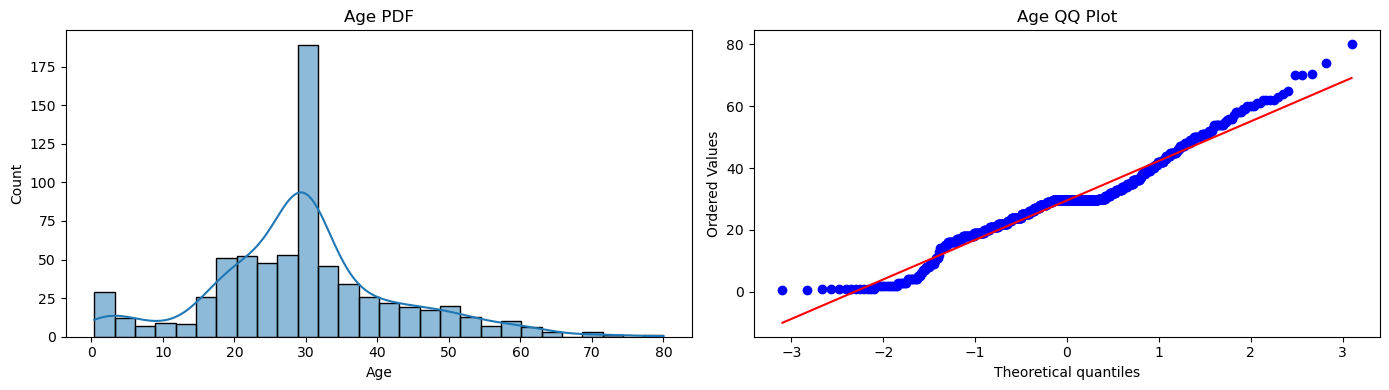

In [63]:
plt.figure(figsize=(14,4))

plt.subplot(121)
sns.histplot(x_train['Age'], kde=True)
plt.title('Age PDF')

plt.subplot(122)
stats.probplot(x_train['Age'], dist='norm', plot=plt)
plt.title('Age QQ Plot')

plt.tight_layout()
plt.show()

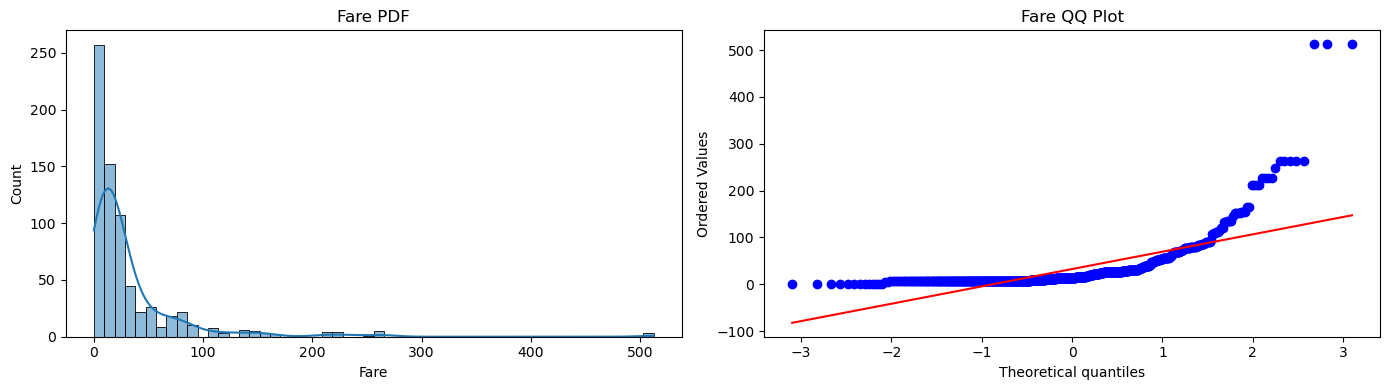

In [65]:
plt.figure(figsize=(14,4))

plt.subplot(121)
sns.histplot(x_train['Fare'], kde=True)
plt.title('Fare PDF')

plt.subplot(122)
stats.probplot(x_train['Fare'], dist='norm', plot=plt)
plt.title('Fare QQ Plot')

plt.tight_layout()
plt.show()

In [68]:
clf=LogisticRegression()
clf2=DecisionTreeClassifier()

In [89]:
clf.fit(x_train,y_train)
clf2.fit(x_train,y_train)

y_pred=clf.predict(x_test)
y_pred1=clf2.predict(x_test)

print('Accurscy of lr',accuracy_score(y_test,y_pred))
print('Accurscy of DT',accuracy_score(y_test,y_pred1))


Accurscy of lr 0.6480446927374302
Accurscy of DT 0.6815642458100558


In [90]:
trf=FunctionTransformer(func=np.log1p)

In [91]:
x_train_transformed=trf.fit_transform(x_train)
x_test_transformed=trf.transform(x_test)

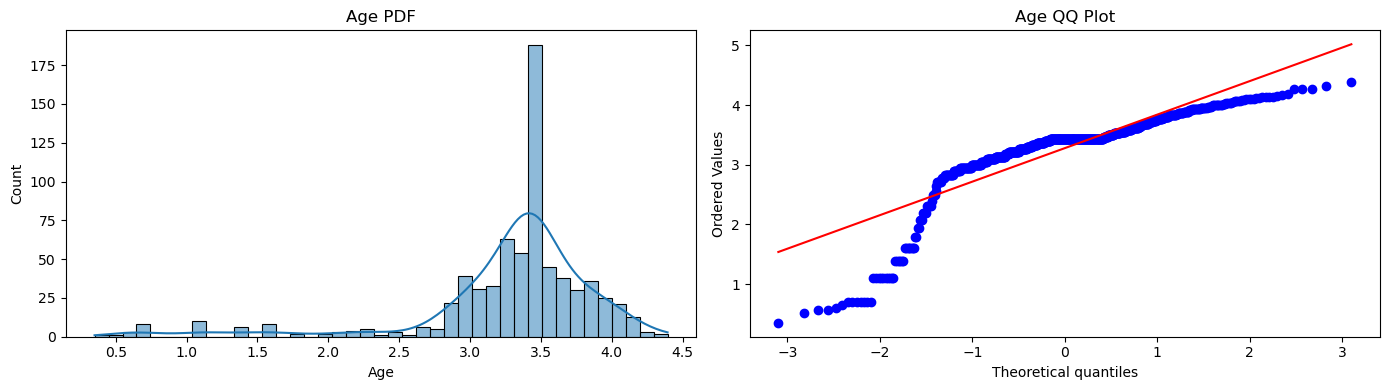

In [92]:
plt.figure(figsize=(14,4))

plt.subplot(121)
sns.histplot(x_train_transformed['Age'], kde=True)
plt.title('Age PDF')

plt.subplot(122)
stats.probplot(x_train_transformed['Age'], dist='norm', plot=plt)
plt.title('Age QQ Plot')

plt.tight_layout()
plt.show()

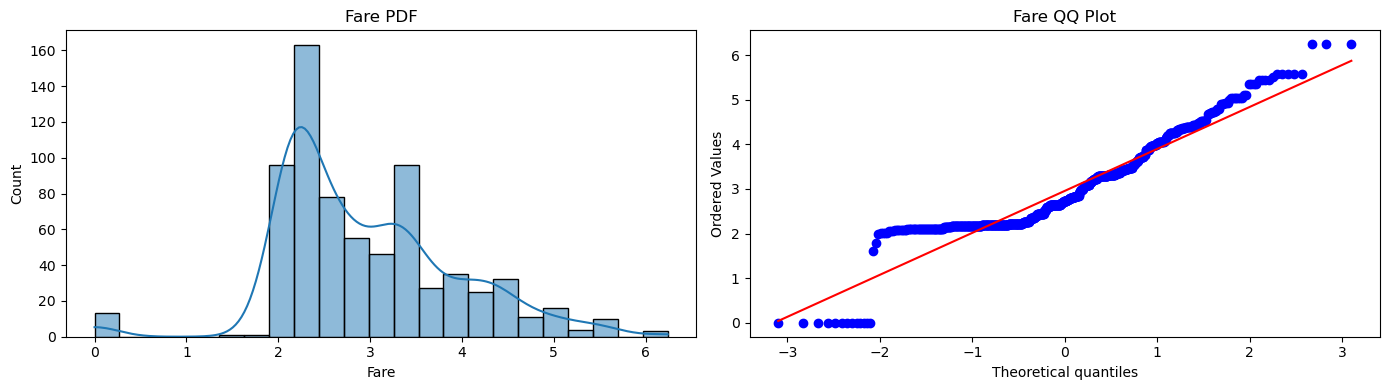

In [93]:
plt.figure(figsize=(14,4))

plt.subplot(121)
sns.histplot(x_train_transformed['Fare'], kde=True)
plt.title('Fare PDF')

plt.subplot(122)
stats.probplot(x_train_transformed['Fare'], dist='norm', plot=plt)
plt.title('Fare QQ Plot')

plt.tight_layout()
plt.show()

In [94]:
clf.fit(x_train_transformed,y_train)
clf2.fit(x_train_transformed,y_train)
   
y_pred_trans=clf.predict(x_test_transformed)
y_pred1_trans=clf2.predict(x_test_transformed)

print('Accurscy of lr',accuracy_score(y_test,y_pred_trans))
print('Accurscy of DT',accuracy_score(y_test,y_pred1_trans))


Accurscy of lr 0.6815642458100558
Accurscy of DT 0.6703910614525139


In [99]:
trf2=ColumnTransformer([('log',FunctionTransformer(np.log1p),['Fare'])],remainder='passthrough')

In [102]:
x_train_transformed2=trf2.fit_transform(x_train)
x_test_transformed2=trf2.transform(x_test)

In [103]:
clf.fit(x_train_transformed2,y_train)
clf2.fit(x_train_transformed2,y_train)
   
y_pred_trans1=clf.predict(x_test_transformed2)
y_pred1_trans2=clf2.predict(x_test_transformed2)

print('Accurscy of lr',accuracy_score(y_test,y_pred_trans1))
print('Accurscy of DT',accuracy_score(y_test,y_pred1_trans2))


Accurscy of lr 0.6703910614525139
Accurscy of DT 0.6815642458100558
